# Model Development

In [69]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)  # Display all columns in the output

# Load the datasets
dis_fact = pd.read_csv('../eda/disasters_fact_table.csv')

dis_fact.head()


,disasterNumber,state,incidentType,declarationDate,incidentBeginDate,incidentEndDate,declarationType,declaration_year,declaration_month,declaration_quarter,incident_duration_days,declaration_lag_days,incident_open_flag,state_disaster_frequency,totalAmountIhpApproved,totalAmountHaApproved,totalAmountOnaApproved,totalObligatedAmountPa,totalObligatedAmountHmgp,target_pa_cost,target_total_recovery_cost,log_target_pa_cost,log_target_total_cost,pa_project_count,pa_total_obligated_sum,pa_total_obligated_mean,pa_total_obligated_median,pa_total_obligated_max,large,small,large_project_ratio,totalAmountIhpApproved_missing,totalAmountHaApproved_missing,totalAmountOnaApproved_missing,totalObligatedAmountPa_missing,totalObligatedAmountHmgp_missing
0,5529,OR,Fire,2024-08-09 00:00:00+00:00,2024-08-08 00:00:00+00:00,NaN,FM,2024,8,3,NaN,1,1,294,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.000000,0.000000,0.0,0.00,0.000000,0.000,0.00,0.0,0.0,0.000000,1,1,1,1,0
1,5528,OR,Fire,2024-08-06 00:00:00+00:00,2024-08-04 00:00:00+00:00,NaN,FM,2024,8,3,NaN,2,1,294,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.000000,0.000000,0.0,0.00,0.000000,0.000,0.00,0.0,0.0,0.000000,1,1,1,1,0
2,5527,OR,Fire,2024-08-02 00:00:00+00:00,2024-08-02 00:00:00+00:00,NaN,FM,2024,8,3,NaN,0,1,294,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.000000,0.000000,0.0,0.00,0.000000,0.000,0.00,0.0,0.0,0.000000,1,1,1,1,0
3,4312,CA,Severe Storm,2017-05-02 00:00:00+00:00,2017-02-08 00:00:00+00:00,2017-02-11 00:00:00+00:00,DR,2017,5,2,3.0,83,0,739,0.0,0.0,0.0,269934.77,1650.00,269934.77,271584.77,12.505939,12.512033,2.0,269934.77,134967.385000,134967.385,233307.18,1.0,1.0,0.500000,1,1,1,0,0
4,4251,AL,Severe Storm,2016-01-21 00:00:00+00:00,2015-12-23 00:00:00+00:00,2015-12-31 00:00:00+00:00,DR,2016,1,1,8.0,29,0,743,0.0,0.0,0.0,36201886.24,5530482.83,36201886.24,41732369.07,17.404622,17.546788,693.0,36201886.01,52239.373752,26674.610,1739135.15,51.0,642.0,0.073593,1,1,1,0,0


In [70]:
dis_fact.columns

Index(['disasterNumber', 'state', 'incidentType', 'declarationDate',
       'incidentBeginDate', 'incidentEndDate', 'declarationType',
       'declaration_year', 'declaration_month', 'declaration_quarter',
       'incident_duration_days', 'declaration_lag_days', 'incident_open_flag',
       'state_disaster_frequency', 'totalAmountIhpApproved',
       'totalAmountHaApproved', 'totalAmountOnaApproved',
       'totalObligatedAmountPa', 'totalObligatedAmountHmgp', 'target_pa_cost',
       'target_total_recovery_cost', 'log_target_pa_cost',
       'log_target_total_cost', 'pa_project_count', 'pa_total_obligated_sum',
       'pa_total_obligated_mean', 'pa_total_obligated_median',
       'pa_total_obligated_max', 'large', 'small', 'large_project_ratio',
       'totalAmountIhpApproved_missing', 'totalAmountHaApproved_missing',
       'totalAmountOnaApproved_missing', 'totalObligatedAmountPa_missing',
       'totalObligatedAmountHmgp_missing'],
      dtype='str')

### Baseline Model

In [71]:
drop_cols = [
    # ids / raw dates
    "disasterNumber",
    "declarationDate",
    "incidentBeginDate",
    "incidentEndDate",

    # targets
    "target_total_recovery_cost",
    "target_pa_cost",
    "log_target_pa_cost",
    "log_target_total_cost",

    # leakage: cost components
    "totalAmountIhpApproved",
    "totalAmountHaApproved",
    "totalAmountOnaApproved",
    "totalObligatedAmountPa",
    "totalObligatedAmountHmgp",

    # leakage: missing flags for target components
    "totalAmountIhpApproved_missing",
    "totalAmountHaApproved_missing",
    "totalAmountOnaApproved_missing",
    "totalObligatedAmountPa_missing",
    "totalObligatedAmountHmgp_missing",

    # leakage: post-event PA aggregates
    "pa_total_obligated_sum",
    "pa_total_obligated_mean",
    "pa_total_obligated_median",
    "pa_total_obligated_max",

    # drop for early-stage baseline
    "pa_project_count",
    "large",
    "small",
    "large_project_ratio",

    # possible time leakage
    "incident_duration_days"
]

In [72]:
X = dis_fact.drop(columns=drop_cols)
y = dis_fact["log_target_total_cost"]

In [73]:
X.columns

Index(['state', 'incidentType', 'declarationType', 'declaration_year',
       'declaration_month', 'declaration_quarter', 'declaration_lag_days',
       'incident_open_flag', 'state_disaster_frequency'],
      dtype='str')

In [74]:
X = pd.get_dummies(X, columns=["state", "incidentType", "declarationType"], drop_first=True)

In [75]:
print(X.select_dtypes(include=["object", "datetime", "datetimetz"]).columns.tolist())

[]


In [76]:
X.isnull().sum().sort_values(ascending=False).head(20)

declaration_year            0
declaration_month           0
declaration_quarter         0
declaration_lag_days        0
incident_open_flag          0
state_disaster_frequency    0
state_AL                    0
state_AR                    0
state_AS                    0
state_AZ                    0
state_CA                    0
state_CO                    0
state_CT                    0
state_DC                    0
state_DE                    0
state_FL                    0
state_GA                    0
state_GU                    0
state_HI                    0
state_IA                    0
dtype: int64

In [77]:
dis_fact[dis_fact['log_target_total_cost'].isnull()].head()

,disasterNumber,state,incidentType,declarationDate,incidentBeginDate,incidentEndDate,declarationType,declaration_year,declaration_month,declaration_quarter,incident_duration_days,declaration_lag_days,incident_open_flag,state_disaster_frequency,totalAmountIhpApproved,totalAmountHaApproved,totalAmountOnaApproved,totalObligatedAmountPa,totalObligatedAmountHmgp,target_pa_cost,target_total_recovery_cost,log_target_pa_cost,log_target_total_cost,pa_project_count,pa_total_obligated_sum,pa_total_obligated_mean,pa_total_obligated_median,pa_total_obligated_max,large,small,large_project_ratio,totalAmountIhpApproved_missing,totalAmountHaApproved_missing,totalAmountOnaApproved_missing,totalObligatedAmountPa_missing,totalObligatedAmountHmgp_missing
21626,3428,CA,Biological,2020-03-13 00:00:00+00:00,2020-01-20 00:00:00+00:00,2023-05-11 00:00:00+00:00,EM,2020,3,1,1207.0,53,0,739,0.0,0.0,0.0,-23499530.3,0.0,-23499530.3,-23499530.3,NaN,NaN,75.0,9048942.72,120652.5696,55404.0,1612389.47,5.0,70.0,0.066667,1,1,1,0,1
21627,3428,CA,Biological,2020-03-13 00:00:00+00:00,2020-01-20 00:00:00+00:00,2023-05-11 00:00:00+00:00,EM,2020,3,1,1207.0,53,0,739,0.0,0.0,0.0,-23499530.3,0.0,-23499530.3,-23499530.3,NaN,NaN,75.0,9048942.72,120652.5696,55404.0,1612389.47,5.0,70.0,0.066667,1,1,1,0,1
21628,3428,CA,Biological,2020-03-13 00:00:00+00:00,2020-01-20 00:00:00+00:00,2023-05-11 00:00:00+00:00,EM,2020,3,1,1207.0,53,0,739,0.0,0.0,0.0,-23499530.3,0.0,-23499530.3,-23499530.3,NaN,NaN,75.0,9048942.72,120652.5696,55404.0,1612389.47,5.0,70.0,0.066667,1,1,1,0,1
21629,3428,CA,Biological,2020-03-13 00:00:00+00:00,2020-01-20 00:00:00+00:00,2023-05-11 00:00:00+00:00,EM,2020,3,1,1207.0,53,0,739,0.0,0.0,0.0,-23499530.3,0.0,-23499530.3,-23499530.3,NaN,NaN,75.0,9048942.72,120652.5696,55404.0,1612389.47,5.0,70.0,0.066667,1,1,1,0,1
21630,3428,CA,Biological,2020-03-13 00:00:00+00:00,2020-01-20 00:00:00+00:00,2023-05-11 00:00:00+00:00,EM,2020,3,1,1207.0,53,0,739,0.0,0.0,0.0,-23499530.3,0.0,-23499530.3,-23499530.3,NaN,NaN,75.0,9048942.72,120652.5696,55404.0,1612389.47,5.0,70.0,0.066667,1,1,1,0,1


In [78]:
X = X.fillna(0)
y = y.fillna(0)

In [79]:
X.isnull().sum().sort_values(ascending=False).head(20)

declaration_year            0
declaration_month           0
declaration_quarter         0
declaration_lag_days        0
incident_open_flag          0
state_disaster_frequency    0
state_AL                    0
state_AR                    0
state_AS                    0
state_AZ                    0
state_CA                    0
state_CO                    0
state_CT                    0
state_DC                    0
state_DE                    0
state_FL                    0
state_GA                    0
state_GU                    0
state_HI                    0
state_IA                    0
dtype: int64

In [80]:
y.isnull().sum()

np.int64(0)

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [82]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [83]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{name} Results:")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    print("-" * 30)

evaluate(y_test, y_pred_lr, "Linear Regression")

Linear Regression Results:
RMSE: 3.3623
R²: 0.8405
------------------------------


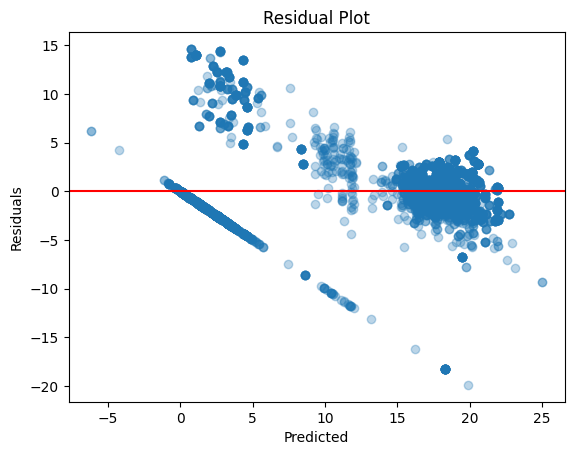

In [84]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_lr

plt.scatter(y_pred_lr, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

Clear diagonal line and distinct clusters. This means disaster cost doesn't fit linearly, more non-linear and segmented.